In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
folder_path = r"D:\MSC THESIS AAVAS\Analysis Part\Whole data"

In [3]:
files = [f for f in os.listdir(folder_path) if f.endswith(".xlsx")]
print("Total files:", len(files))
print(files)

Total files: 4
['Whole_data_bp.xlsx', 'Whole_data_NNM.xlsx', 'Whole_data_yam_bag.xlsx', 'Whole_data_yam_bag_o.xlsx']


In [4]:
results = []

In [5]:
sample_file = os.path.join(folder_path, files[0])
df = pd.read_excel(sample_file)

print(df.head())
print(df.columns)

  Chainage   Speeds   Unit  85th Percentile Speed
0     1+830      43  km/hr                   57.0
1       NaN      41  km/hr                    NaN
2       NaN      82  km/hr                    NaN
3       NaN      43  km/hr                    NaN
4       NaN      46  km/hr                    NaN
Index(['Chainage ', 'Speeds', 'Unit', '85th Percentile Speed'], dtype='str')


In [6]:
for file in files:
    file_path = os.path.join(folder_path, file)
    xls = pd.ExcelFile(file_path)

    cleaned_output_path = os.path.join(folder_path, f"Cleaned_{file}")

    with pd.ExcelWriter(cleaned_output_path, engine="openpyxl") as writer:

        for sheet in xls.sheet_names:
            df = pd.read_excel(file_path, sheet_name=sheet)
            df.columns = df.columns.str.strip()

            # Extract speed data
            data = df["Speeds"].dropna()

            # Original V85
            V85_original = np.percentile(data, 85)

            # IQR method
            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Cleaned speeds
            clean_data = data[(data >= lower_bound) & (data <= upper_bound)]

            # Cleaned V85
            V85_cleaned = np.percentile(clean_data, 85)

            # Save cleaned speeds in same sheet name
            clean_df = pd.DataFrame({"Speeds": clean_data.reset_index(drop=True)})
            clean_df.to_excel(writer, sheet_name=sheet, index=False)

            # Store summary
            results.append({
                "File": file,
                "Sheet": sheet,
                "Original_Data_Count": len(data),
                "Cleaned_Data_Count": len(clean_data),
                "Outliers_Removed": len(data) - len(clean_data),
                "V85_Original": V85_original,
                "V85_Cleaned": V85_cleaned
            })

    print(f"Finished processing: {file}")

Finished processing: Whole_data_bp.xlsx
Finished processing: Whole_data_NNM.xlsx
Finished processing: Whole_data_yam_bag.xlsx
Finished processing: Whole_data_yam_bag_o.xlsx


In [7]:
result_df = pd.DataFrame(results)
result_df

,File,Sheet,Original_Data_Count,Cleaned_Data_Count,Outliers_Removed,V85_Original,V85_Cleaned
0,Whole_data_bp.xlsx,Point 1,105,104,1,57.00,57.00
1,Whole_data_bp.xlsx,Point 2,106,102,4,33.25,33.00
2,Whole_data_bp.xlsx,Point 3,103,102,1,43.00,43.00
3,Whole_data_bp.xlsx,Point 4,102,102,0,48.00,48.00
4,Whole_data_bp.xlsx,Point 5,106,104,2,36.00,36.00
...,...,...,...,...,...,...,...
137,Whole_data_yam_bag_o.xlsx,Point25,140,136,4,58.15,58.75
138,Whole_data_yam_bag_o.xlsx,Point 26,110,110,0,54.00,54.00
139,Whole_data_yam_bag_o.xlsx,Point27,140,134,6,59.15,60.00
140,Whole_data_yam_bag_o.xlsx,Point 28,107,107,0,44.00,44.00


In [8]:
summary_output_path = os.path.join(folder_path, "V85_Cleaned_Summary.xlsx")
result_df.to_excel(summary_output_path, index=False)

print("Summary file saved at:")
print(summary_output_path)

Summary file saved at:
D:\MSC THESIS AAVAS\Analysis Part\Whole data\V85_Cleaned_Summary.xlsx


In [9]:
result_df.head()

,File,Sheet,Original_Data_Count,Cleaned_Data_Count,Outliers_Removed,V85_Original,V85_Cleaned
0,Whole_data_bp.xlsx,Point 1,105,104,1,57.00,57.0
1,Whole_data_bp.xlsx,Point 2,106,102,4,33.25,33.0
2,Whole_data_bp.xlsx,Point 3,103,102,1,43.00,43.0
3,Whole_data_bp.xlsx,Point 4,102,102,0,48.00,48.0
4,Whole_data_bp.xlsx,Point 5,106,104,2,36.00,36.0


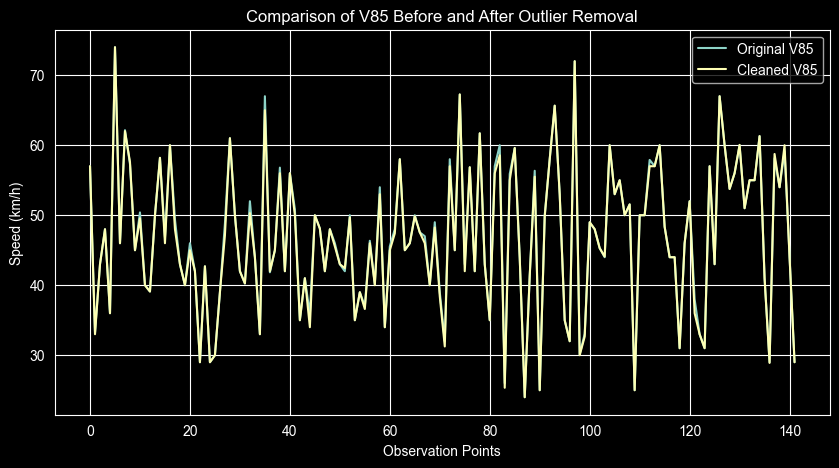

In [10]:
plt.figure(figsize=(10,5))
plt.plot(result_df['V85_Original'], label='Original V85')
plt.plot(result_df['V85_Cleaned'], label='Cleaned V85')
plt.legend()
plt.title("Comparison of V85 Before and After Outlier Removal")
plt.ylabel("Speed (km/h)")
plt.xlabel("Observation Points")
plt.show()